# Workshop: Understanding the Convolution Operator (`nn.Conv2d`)

**Objective:** 
In this workshop, we will cover the 2D Convolution operator in PyTorch. 

We will start from the basics of input data dimensions, move to applying a single convolution layer with custom kernels, understand how learnable parameters are calculated, and finally see how multiple layers are stacked to form a network.

**Key Concepts:**
1.  Input Data Structure (Batch, Channels, Height, Width)
2.  The Convolution Operation (`nn.Conv2d`)
3.  Learnable Parameters (Weights & Bias)
4.  Stacking Multiple Layers (Feature Extraction Flow)

In [35]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

## Part 1: The Input Data (Image)

Before applying convolution, we must understand the input data structure. 

PyTorch expects image data in a specific format:
$$ (Batch, Channels, Height, Width) $$

- **Batch ($B$)**: Number of images processed simultaneously.
- **Channels ($C$)**: Number of color channels (e.g., 1 for Grayscale, 3 for RGB).
- **Height ($H$) & Width ($W$)**: Spatial dimensions of the image.

Let's create a synthetic 10x10 grayscale image with a simple cross pattern.

In [ ]:
# 1. Create a synthetic image tensor
# Shape: (Batch=1, Channels=1, Height=10, Width=10) or (in_channels=1, out_channels=1, kernel_size=10, kernel_size=10)
image = torch.zeros(1, 1, 10, 10)

# 2. Draw a pattern (Cross)
# Vertical line at columns 4 and 5
image[0, 0, :, 4:6] = 1.0
# Horizontal line at rows 4 and 5
image[0, 0, 4:6, :] = 1.0

# 3. Inspect Properties
print("Input Image Properties:")
print(f"Shape: {image.shape}")
print(f"Rank (ndim): {image.ndim}")
print(f"Data Type: {image.dtype}")
print(f"Device: {image.device}")

Input Image Properties:
Shape: torch.Size([1, 1, 10, 10])
Rank (ndim): 4
Data Type: torch.float32
Device: cpu


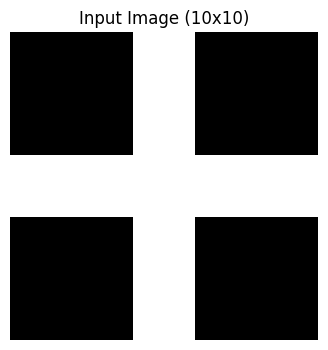

In [38]:
# Helper function to visualize tensors
def plot_tensor(tensor, title="Tensor"):
    
    img_np = tensor.detach().cpu().squeeze().numpy() # Detach from DAG - graph, move to cpu, squeeze batch/channel dims for plotting
    
    plt.figure(figsize=(4, 4))
    plt.imshow(img_np, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

plot_tensor(image, "Input Image (10x10)")

## Part 2: The Convolution Operation (`nn.Conv2d`)

The `nn.Conv2d` layer performs the convolution operation. Key parameters:
- `in_channels`: Depth of input feature map.
- `out_channels`: Number of kernels (filters) to apply. This determines the depth of the output.
- `kernel_size`: Size of the sliding window or `filters` (e.g., 3x3).
- `stride`: Step size of the sliding window.
- `padding`: Zero-padding added to borders to control output size.

### Manual Kernel Demonstration
To understand what convolution *does*, we will manually set the weights of a Conv2d layer to act as edge detectors.

In [39]:
# Define custom kernels

# Vertical Edge Detector (Sobel-like)
k_vertical = torch.tensor([
    [-1., 0., 1.],
    [-2., 0., 2.],
    [-1., 0., 1.]
]).unsqueeze(0).unsqueeze(0) # Shape: (Out=1, In=1, H=3, W=3)

# Horizontal Edge Detector
k_horizontal = torch.tensor([
    [-1., -2., -1.],
    [ 0.,  0.,  0.],
    [ 1.,  2.,  1.]
]).unsqueeze(0).unsqueeze(0) # Shape: (Out=1, In=1, H=3, W=3)

print(f"Kernel Shape: {k_vertical.shape} -> (Out_Channels, In_Channels, Kernel_H, Kernel_W)")

Kernel Shape: torch.Size([1, 1, 3, 3]) -> (Out_Channels, In_Channels, Kernel_H, Kernel_W)


### Initialize a Conv2d layer
Conv2d in pytorch is a 2D convolution operator.

Conv2d is a learnable layer that takes an input tensor and applies a convolution operation to it.

In [42]:
# We use padding=1 to keep the output spatial dimensions same as input (10x10)
conv_1 = nn.Conv2d(in_channels=1, out_channels=1, kernel_size=3, padding=1, bias=False)
conv_2 = nn.Conv2d(in_channels=1, out_channels=5, kernel_size=3)
# conv_1.parameters()


In [44]:
# 1. Apply Vertical Kernel
with torch.no_grad():
    conv_1.weight = nn.Parameter(k_vertical)
    output_vertical = conv_1(image)

# 2. Apply Horizontal Kernel
with torch.no_grad():
    conv_1.weight = nn.Parameter(k_horizontal)
    output_horizontal = conv_1(image)

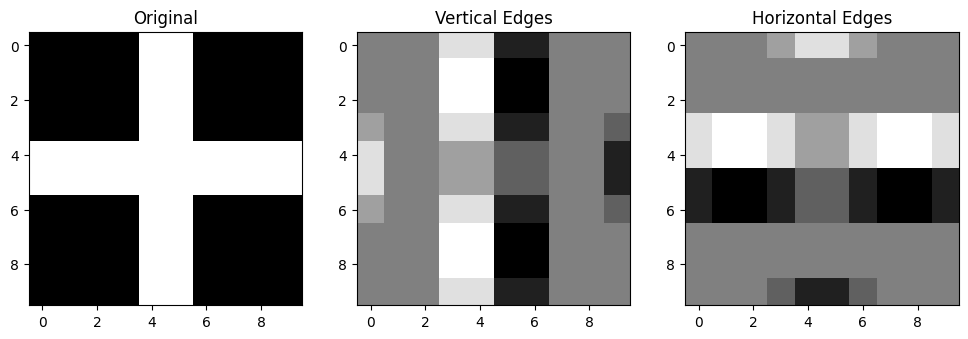

In [45]:
# Visualize
plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1); plt.imshow(image.squeeze(), cmap='gray'); plt.title("Original")
plt.subplot(1, 3, 2); plt.imshow(output_vertical.squeeze(), cmap='gray'); plt.title("Vertical Edges")
plt.subplot(1, 3, 3); plt.imshow(output_horizontal.squeeze(), cmap='gray'); plt.title("Horizontal Edges")
plt.show()

## Part 3: Learnable Parameters

In a real neural network, we don't manually set weights. 

They are **learnable parameters** initialized randomly and updated during training.

### Parameter Calculation Formula
For a Conv2d layer, the number of parameters is:

$$ \text{Weights} = \text{in\_channels} \times \text{out\_channels} \times \text{kernel\_height} \times \text{kernel\_width} $$
$$ \text{Bias} = \text{out\_channels} \quad (\text{if bias=True}) $$
$$ \text{Total} = \text{Weights} + \text{Bias} $$

In [48]:
# Example Layer: 3 Input Channels (RGB), 16 Output Channels, 3x3 Kernel
conv_layer = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, bias=True)

# Manual Calculation
# Weights: 16 * 3 * 3 * 3 = 432
# Bias: 16
# Total: 448

In [54]:
# PyTorch Calculation
total_params = sum(p.numel() for p in conv_layer.parameters())

print(f"Layer Configuration: {conv_layer}")
print(f"Weight Shape: {conv_layer.weight.shape}")
print(f"Bias Shape: {conv_layer.bias.shape}")
print(f"Total Parameters: {total_params}")

Layer Configuration: Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
Weight Shape: torch.Size([16, 3, 3, 3])
Bias Shape: torch.Size([16])
Total Parameters: 448


In [ ]:
# TODO:  print the values of weights and biases

## Part 4: Stacking Multiple Layers (The Flow)

- Deep Learning power comes from stacking multiple layers. 
- The **Output** of one layer becomes the **Input** of the next. `(Imp: Neural Network Flow)`

### The Transformation Flow
1.  **Channel Transformation**: We usually increase the number of channels deeper in the network (e.g., 3 -> 16 -> 32) to capture more complex features.
2.  **Spatial Transformation**: The Height and Width ($H, W$) change based on kernel size, stride, and padding.

$$ O_{out} = \lfloor\frac{N_{in} + 2 \times \text{padding} - \text{kernel\_size}}{\text{stride}} + 1\rfloor $$

In [ ]:
# Define a simple sequential model

model = nn.Sequential(
    # Layer 1: 1 -> 16 channels
    nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
    nn.ReLU(), # Activation function (does not change shape)
    
    # Layer 2: 16 -> 32 channels
    nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU()

    # Add a new Layer 3?
)

In [53]:
# Create a dummy input batch of 8 images
# Shape: (Batch=8, Channels=1, Height=10, Width=10)
input_tensor = torch.randn(8, 1, 10, 10)

# Pass through the model
output_tensor = model(input_tensor)

print("Flow Analysis:")
print(f"1. Input Shape:  {input_tensor.shape}")
print(f"   ... passing through model ...")
print(f"2. Output Shape: {output_tensor.shape}")

print("\nNote: The spatial dimensions (10x10) remained the same because we used padding=1 with kernel_size=3.")

Flow Analysis:
1. Input Shape:  torch.Size([8, 1, 10, 10])
   ... passing through model ...
2. Output Shape: torch.Size([8, 32, 10, 10])

Note: The spatial dimensions (10x10) remained the same because we used padding=1 with kernel_size=3.


## Conclusion

We have covered the lifecycle of the Convolution operator:
1.  **Input**: Requires `(B, C, H, W)` format.
2.  **Operation**: `nn.Conv2d` slides kernels to extract features.
3.  **Parameters**: Weights are learned during training; their count depends on kernel size and depth.
4.  **Stacking**: Layers are chained to transform data from raw pixels into high-level feature maps (increasing channels, often decreasing spatial size).